# OTP specialization and win probability

This notebook estimates whether champion specialization is associated with winning after accounting for matchup strength, rank, lane, side, and champion. The goal is interpretation—not production match prediction.

The current patch sample is provisional. Rerun this notebook after expanding the Riot collection window.

## 1. Imports

If `statsmodels` is unavailable, run `%pip install statsmodels` once and restart the kernel.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

def display_percentages(frame, columns, digits=2, signed=()):
    output = frame.copy()
    for column in columns:
        if column in output:
            sign = '+' if column in signed else ''
            output[column] = output[column].map(
                lambda value: f'{value:{sign}.{digits}%}' if pd.notna(value) else ''
            )
    display(output)

## 2. Load and prepare the modeling sample

The complete parquet remains unchanged. The 50-match matchup cutoff and all transformations happen in memory.

In [2]:
start_dir = Path.cwd().resolve()
search_dirs = [start_dir, *start_dir.parents]
PROJECT_DIR = next(
    (path for path in search_dirs if (path / 'data' / 'processed').exists()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError('Could not find the repository data/processed directory.')

DATA_PATH = PROJECT_DIR / 'data' / 'processed' / 'otp_analysis_16_19.parquet'
raw_df = pd.read_parquet(DATA_PATH)

required = {
    'match_id', 'puuid', 'seed_tier', 'side', 'lane', 'champion', 'win',
    'champion_share', 'raw_matchup_winrate', 'matchup_games',
    'matchup_games_ge_50',
}
missing = required.difference(raw_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

model_df = (
    raw_df.loc[raw_df['matchup_games_ge_50']].copy()
    .rename(columns={'seed_tier': 'rank', 'champion_share': 'otp_rate'})
)
model_df['win'] = model_df['win'].astype(int)
model_df['otp_rate'] = pd.to_numeric(model_df['otp_rate'], errors='coerce')
model_df['matchup_winrate'] = (
    pd.to_numeric(model_df['raw_matchup_winrate'], errors='coerce') / 100
)

# Scaling makes the coefficients readable.
# One unit of otp_rate_10pp = a 10-percentage-point increase in champion usage.
# One unit of matchup_winrate_1pp = a 1-percentage-point matchup advantage.
model_df['otp_rate_10pp'] = model_df['otp_rate'] * 10
model_df['matchup_winrate_1pp'] = model_df['matchup_winrate'] * 100

model_columns = [
    'match_id', 'puuid', 'win', 'otp_rate', 'otp_rate_10pp',
    'matchup_winrate', 'matchup_winrate_1pp',
    'rank', 'lane', 'side', 'champion',
]
model_df = model_df.loc[:, model_columns].dropna().reset_index(drop=True)

print('Source:', DATA_PATH)
print('Modeling rows:', f'{len(model_df):,}')
print('Unique matches:', f"{model_df['match_id'].nunique():,}")
print('Unique players:', f"{model_df['puuid'].nunique():,}")
display(model_df.head())

Source: /Users/minhho-hoang/Documents/riot_proj/riot-game-prediction/data/processed/otp_analysis_16_19.parquet
Modeling rows: 11,001
Unique matches: 2,701
Unique players: 1,736


,match_id,puuid,win,otp_rate,otp_rate_10pp,matchup_winrate,matchup_winrate_1pp,rank,lane,side,champion
0,NA1_5647500766,dx-RQgITH4zEEw4nOcQ1RXhDCYDPhDrqAPJP-spqoWgz9-...,0,0.5000,5.0000,0.6000,60.0000,master,adc,blue,Caitlyn
1,NA1_5647500766,xr230ZbE7-uZm_ExI5Lu5ALBpdaV2znPVFHta51ndjICYe...,1,0.9375,9.3750,0.4138,41.3800,master,adc,red,Vladimir
2,NA1_5647504796,Ppm5R3jem_xRbN6ol0qaK55X4R-Nx2NtAISrJvNq9ETqe0...,0,0.9118,9.1176,0.4790,47.9000,master,jungle,red,Chogath
3,NA1_5647504796,pIGMMqaoXkuMAs8Rv2Ig1RynU4USm9acy9SeOry8IK8JX_...,0,0.2500,2.5000,0.4419,44.1900,master,support,red,Leona
4,NA1_5647497841,LDk1guhzOXvgZh6wXiI1dEPrk-rFAUBvB1A_tzraBbl1ib...,1,0.7143,7.1429,0.5418,54.1800,grandmaster,adc,blue,Syndra


## 3. Modeling checks

The outcome must be binary, rates must be valid, and each sampled player should appear at most once per match.

In [3]:
assert model_df['win'].isin([0, 1]).all()
assert model_df['otp_rate'].between(0, 1).all()
assert model_df['matchup_winrate'].between(0, 1).all()
assert model_df.duplicated(['match_id', 'puuid']).sum() == 0

audit = pd.Series({
    'player rows': len(model_df),
    'unique matches': model_df['match_id'].nunique(),
    'unique players': model_df['puuid'].nunique(),
    'actual win rate': model_df['win'].mean(),
    'average OTP rate': model_df['otp_rate'].mean(),
    'average raw matchup WR': model_df['matchup_winrate'].mean(),
})
display(audit.to_frame('value'))

,value
player rows,"11,001.0000"
unique matches,"2,701.0000"
unique players,"1,736.0000"
actual win rate,0.5229
average OTP rate,0.4075
average raw matchup WR,0.5116


## 4. Primary models: linear probability models

A linear probability model makes the OTP coefficient directly interpretable as a change in win probability. Standard errors are clustered by both match and player because multiple sampled observations can share a match and each player can appear repeatedly.

- **Model 0:** unadjusted OTP association
- **Model 1:** adds matchup, rank, lane, and side
- **Model 2:** additionally compares players while controlling for champion

In [4]:
def fit_lpm(formula, data):
    model = smf.ols(formula, data=data)
    two_way_groups = data[['match_id', 'puuid']]
    try:
        return model.fit(
            cov_type='cluster',
            cov_kwds={'groups': two_way_groups, 'use_correction': True},
        )
    except (ValueError, TypeError) as error:
        warnings.warn(
            'This statsmodels version did not accept two-way clustering; '
            'falling back to match-clustered standard errors. Original error: '
            f'{error}'
        )
        return model.fit(
            cov_type='cluster',
            cov_kwds={'groups': data['match_id'], 'use_correction': True},
        )

formulas = {
    'Model 0: OTP only': 'win ~ otp_rate_10pp',
    'Model 1: core controls': (
        'win ~ otp_rate_10pp + matchup_winrate_1pp '
        '+ C(rank) + C(lane) + C(side)'
    ),
    'Model 2: + champion': (
        'win ~ otp_rate_10pp + matchup_winrate_1pp '
        '+ C(rank) + C(lane) + C(side) + C(champion)'
    ),
}

lpm_models = {name: fit_lpm(formula, model_df) for name, formula in formulas.items()}
print('Models fitted:', ', '.join(lpm_models))

/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(
/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(


Models fitted: Model 0: OTP only, Model 1: core controls, Model 2: + champion


/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(


,model,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value,rows,r_squared
0,Model 0: OTP only,0.4954,0.2173,0.7736,0.0005,11001,0.0010
1,Model 1: core controls,0.5379,0.2470,0.8288,0.0003,11001,0.0102
2,Model 2: + champion,0.3828,0.0570,0.7086,0.0213,11001,0.0220


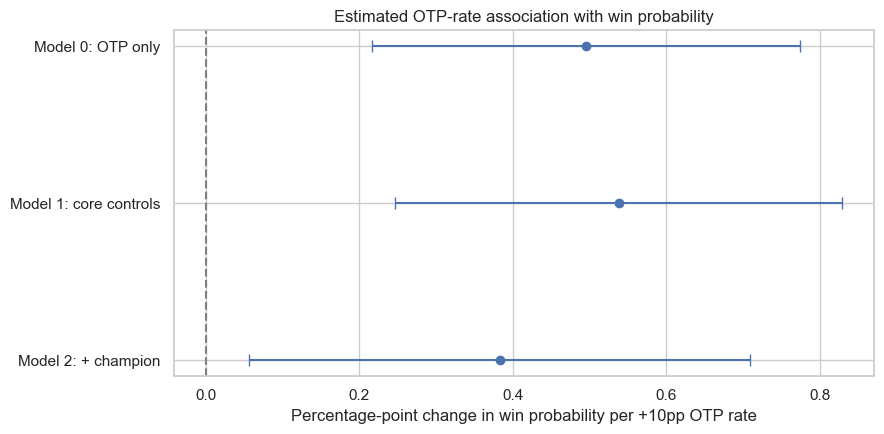

In [5]:
def otp_result_row(name, fitted_model):
    term = 'otp_rate_10pp'
    ci_low, ci_high = fitted_model.conf_int().loc[term]
    return {
        'model': name,
        'effect_pp_per_10pp_otp': fitted_model.params[term] * 100,
        'ci_low_pp': ci_low * 100,
        'ci_high_pp': ci_high * 100,
        'p_value': fitted_model.pvalues[term],
        'rows': int(fitted_model.nobs),
        'r_squared': fitted_model.rsquared,
    }

otp_model_results = pd.DataFrame([
    otp_result_row(name, fitted_model)
    for name, fitted_model in lpm_models.items()
])
display(otp_model_results)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_table = otp_model_results.iloc[::-1].reset_index(drop=True)
ax.errorbar(
    plot_table['effect_pp_per_10pp_otp'],
    plot_table['model'],
    xerr=[
        plot_table['effect_pp_per_10pp_otp'] - plot_table['ci_low_pp'],
        plot_table['ci_high_pp'] - plot_table['effect_pp_per_10pp_otp'],
    ],
    fmt='o',
    capsize=4,
)
ax.axvline(0, color='gray', linestyle='--')
ax.set(
    title='Estimated OTP-rate association with win probability',
    xlabel='Percentage-point change in win probability per +10pp OTP rate',
    ylabel='',
)
plt.tight_layout()
plt.show()

In [6]:
main_lpm = lpm_models['Model 2: + champion']
effect = main_lpm.params['otp_rate_10pp'] * 100
ci_low, ci_high = main_lpm.conf_int().loc['otp_rate_10pp'] * 100
p_value = main_lpm.pvalues['otp_rate_10pp']
direction = 'increase' if effect >= 0 else 'decrease'

print(
    f'After adjustment, a 10-percentage-point increase in OTP rate is associated '
    f'with a {abs(effect):.2f}-percentage-point {direction} in win probability '
    f'(95% CI: {ci_low:.2f} to {ci_high:.2f}; p={p_value:.4f}).'
)

After adjustment, a 10-percentage-point increase in OTP rate is associated with a 0.38-percentage-point increase in win probability (95% CI: 0.06 to 0.71; p=0.0213).


## 5. Logistic-regression robustness check

Logistic regression respects the 0–1 probability boundary. The code translates its result into the average predicted win-probability change from increasing OTP rate by 10 percentage points. Standard errors for the fitted coefficients are clustered by match; the two-way-clustered linear model remains the primary inference.

In [7]:
logit_model = smf.glm(
    formulas['Model 2: + champion'],
    data=model_df,
    family=sm.families.Binomial(),
).fit(
    cov_type='cluster',
    cov_kwds={'groups': model_df['match_id'], 'use_correction': True},
)

# Compare each eligible row with itself at an OTP rate 10 percentage points higher.
eligible = model_df.loc[model_df['otp_rate'] <= 0.90].copy()
higher_otp = eligible.copy()
higher_otp['otp_rate'] += 0.10
higher_otp['otp_rate_10pp'] += 1
logit_effect_pp = (
    logit_model.predict(higher_otp) - logit_model.predict(eligible)
).mean() * 100

print(
    'Logistic-model average probability change for +10pp OTP rate: '
    f'{logit_effect_pp:+.2f} percentage points'
)
print(
    'Logistic OTP coefficient p-value (match-clustered): '
    f"{logit_model.pvalues['otp_rate_10pp']:.4f}"
)

Logistic-model average probability change for +10pp OTP rate: +0.38 percentage points
Logistic OTP coefficient p-value (match-clustered): 0.0212


## 6. Break-even matchup advantage

This converts the controlled model into the project’s central decision question: how much better must an alternative champion’s matchup be to offset the estimated familiarity advantage of the main? This is a population-level estimate, not an individualized champion-select recommendation.

In [12]:
otp_coef = main_lpm.params['otp_rate_10pp']
matchup_coef = main_lpm.params['matchup_winrate_1pp']

def break_even_matchup_points(main_otp_rate, alternative_otp_rate):
    if np.isclose(matchup_coef, 0):
        return np.nan
    otp_gap_in_10pp_units = (main_otp_rate - alternative_otp_rate) * 10
    return otp_coef * otp_gap_in_10pp_units / matchup_coef

example_pairs = pd.DataFrame({
    # These are feasible shares for the same player: each pair sums to at most 100%.
    'main_otp_rate': [0.60, 0.70, 0.80, 0.90],
    'alternative_otp_rate': [0.40, 0.30, 0.20, 0.10],
})
example_pairs['otp_rate_gap'] = (
    example_pairs['main_otp_rate'] - example_pairs['alternative_otp_rate']
)
example_pairs['break_even_matchup_advantage_pp'] = example_pairs.apply(
    lambda row: break_even_matchup_points(
        row['main_otp_rate'], row['alternative_otp_rate']
    ),
    axis=1,
)
display_percentages(
    example_pairs,
    ['main_otp_rate', 'alternative_otp_rate', 'otp_rate_gap'],
    digits=0,
)

if matchup_coef <= 0:
    print(
        'Warning: the fitted matchup coefficient is not positive, so the break-even '
        'calculation should not be interpreted yet.'
    )

,main_otp_rate,alternative_otp_rate,otp_rate_gap,break_even_matchup_advantage_pp
0,60%,40%,20%,0.8050
1,70%,30%,40%,1.6100
2,80%,20%,60%,2.4151
3,90%,10%,80%,3.2201


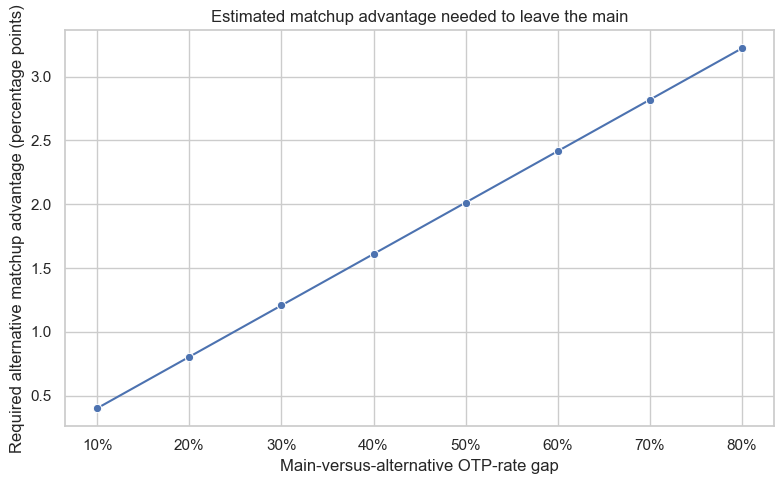

In [9]:
otp_gaps = np.arange(0.10, 0.81, 0.10)
break_even_curve = pd.DataFrame({
    'otp_rate_gap': otp_gaps,
    'break_even_matchup_advantage_pp': [
        break_even_matchup_points(gap, 0) for gap in otp_gaps
    ],
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=break_even_curve,
    x='otp_rate_gap',
    y='break_even_matchup_advantage_pp',
    marker='o',
    ax=ax,
)
ax.xaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
ax.set(
    title='Estimated matchup advantage needed to leave the main',
    xlabel='Main-versus-alternative OTP-rate gap',
    ylabel='Required alternative matchup advantage (percentage points)',
)
plt.tight_layout()
plt.show()

## 7. Does the OTP association differ by rank or lane?

These are separate controlled models inside each subgroup. Treat estimates from small groups cautiously and compare their confidence intervals, not only their point estimates.

In [10]:
def subgroup_effects(data, group_column, group_values):
    rows = []
    for value in group_values:
        subset = data.loc[data[group_column] == value].copy()
        if len(subset) < 100:
            continue

        remaining_group = 'lane' if group_column == 'rank' else 'rank'
        formula = (
            'win ~ otp_rate_10pp + matchup_winrate_1pp '
            f'+ C({remaining_group}) + C(side) + C(champion)'
        )
        fitted = fit_lpm(formula, subset)
        ci_low, ci_high = fitted.conf_int().loc['otp_rate_10pp']
        rows.append({
            group_column: value,
            'player_rows': len(subset),
            'unique_players': subset['puuid'].nunique(),
            'effect_pp_per_10pp_otp': fitted.params['otp_rate_10pp'] * 100,
            'ci_low_pp': ci_low * 100,
            'ci_high_pp': ci_high * 100,
            'p_value': fitted.pvalues['otp_rate_10pp'],
        })
    return pd.DataFrame(rows)

rank_order = ['master', 'grandmaster', 'challenger']
lane_order = ['top', 'jungle', 'mid', 'adc', 'support']
rank_effects = subgroup_effects(model_df, 'rank', rank_order)
lane_effects = subgroup_effects(model_df, 'lane', lane_order)

print('By rank')
display(rank_effects)
print('By lane')
display(lane_effects)

/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(
/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(
/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; falling back to match-clustered standard errors. Original error: Cannot change data-type for object array.
  warnings.warn(
/var/folders/r9/mhc5twwx0blgr6rw0wr28jmc0000gn/T/ipykernel_58266/2447490876.py:10: UserWarning: This statsmodels version did not accept two-way clustering; fall

By rank


,rank,player_rows,unique_players,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value
0,master,3191,929,0.2106,-0.3545,0.7756,0.4651
1,grandmaster,5154,557,0.7765,0.2489,1.3041,0.0039
2,challenger,2656,250,0.2048,-0.7497,1.1593,0.6741


By lane


,lane,player_rows,unique_players,effect_pp_per_10pp_otp,ci_low_pp,ci_high_pp,p_value
0,top,1932,542,0.3836,-0.3449,1.1120,0.3021
1,jungle,2195,545,0.4378,-0.3007,1.1762,0.2453
2,mid,2265,567,0.6187,-0.1177,1.3552,0.0996
3,adc,2356,598,0.3015,-0.5116,1.1147,0.4673
4,support,2253,622,0.3467,-0.3725,1.0660,0.3448


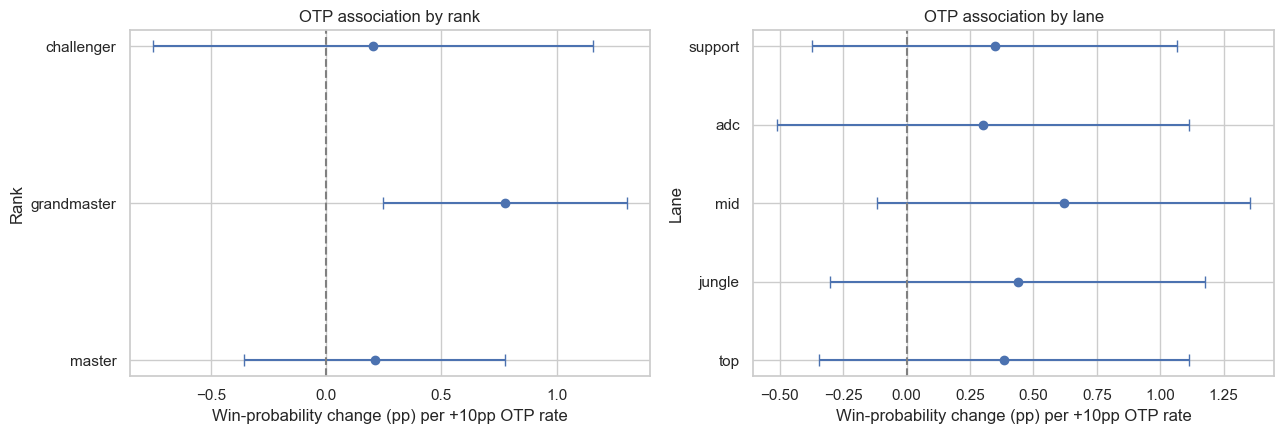

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for table, label, axis in [
    (rank_effects, 'rank', axes[0]),
    (lane_effects, 'lane', axes[1]),
]:
    axis.errorbar(
        table['effect_pp_per_10pp_otp'],
        table[label],
        xerr=[
            table['effect_pp_per_10pp_otp'] - table['ci_low_pp'],
            table['ci_high_pp'] - table['effect_pp_per_10pp_otp'],
        ],
        fmt='o',
        capsize=4,
    )
    axis.axvline(0, color='gray', linestyle='--')
    axis.set(
        title=f'OTP association by {label}',
        xlabel='Win-probability change (pp) per +10pp OTP rate',
        ylabel=label.title(),
    )
plt.tight_layout()
plt.show()

## Interpretation rules

1. Use **Model 2** as the main adjusted estimate and Model 0 only as the unadjusted comparison.
2. Interpret the OTP estimate as an **association**, not a causal effect.
3. A confidence interval crossing zero means the current sample does not precisely distinguish the estimate from no association.
4. The break-even calculation is a population-level summary; it does not reveal the unobserved result of an alternative pick in a specific match.
5. `otp_rate` currently summarizes the short patch window and may use games occurring after a given match. A later version should construct pre-game specialization using only games available before each match.
6. Rerun the full collection and this notebook after more patch games accumulate before treating the estimates as final.